In [1]:
!pip install polars pyarrow matplotlib seaborn -q

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

DATA_URL = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv"

In [3]:
df = pl.read_csv(
    DATA_URL,
    ignore_errors=True
)

print("Rows :", df.height)
print("Columns :", df.width)

df.head()

Rows : 49191
Columns : 172


ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,…,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
1,"""I am a developer by profession""","""25-34 years old""","""Master’s degree (M.A., M.S., M…","""Employed""","""Caring for dependents (childre…","""8""","""Yes, I am not new to coding bu…","""Online Courses or Certificatio…","""Yes, I learned how to use AI-e…","""AI CodeGen tools or AI-enabled…","""14""","""Developer, mobile""","""20 to 99 employees""","""People manager""","""Remote""","""Yes, I influenced the purchase…","""Work""","""10""","""7""","""9""","""6""","""3""","""11""","""12""","""1""","""8""","""14""","""NA""","""15""","""7""","""8""","""12""","""11""","""1""","""6""","""13""",…,"""Yes, I use AI tools monthly or…","""Indifferent""","""Neither trust nor distrust""","""Bad at handling complex tasks""","""Learning about a codebase;Writ…","""Project planning;Deployment an…","""Documenting code;Debugging or …","""NA""","""NA""","""AI solutions that are almost r…","""No""","""Yes, I use AI agents at work m…","""Not at all or minimally""","""Software engineering""","""NA""","""AI agents have increased my pr…","""AI agents have helped me autom…","""NA""","""NA""","""NA""","""I am concerned about the accur…","""Integrating AI agents with my …","""The cost of using certain AI a…","""NA""","""NA""","""NA""","""NA""","""Vertex AI""","""NA""","""NA""","""NA""","""ChatGPT""","""NA""","""When I don’t trust AI’s answer…","""Troubleshooting, profiling, de…","""61256""","""10"""
2,"""I am a developer by profession""","""25-34 years old""","""Associate degree (A.A., A.S., …","""Employed""","""NA""","""2""","""Yes, I am not new to coding bu…","""Online Courses or Certificatio…","""Yes, I learned how to use AI-e…","""AI CodeGen tools or AI-enabled…","""10""","""Developer, back-end""","""500 to 999 employees""","""Individual contributor""","""Hybrid (some in-person, leans …","""No""","""Personal Project""","""13""","""1""","""2""","""9""","""4""","""3""","""12""","""5""","""7""","""14""","""NA""","""14""","""1""","""13""","""10""","""9""","""3""","""4""","""2""",…,"""Yes, I use AI tools weekly""","""Indifferent""","""Neither trust nor distrust""","""Bad at handling complex tasks""","""Learning new concepts or techn…","""Learning about a codebase;Proj…","""Writing code;Documenting code;…","""NA""","""NA""","""AI solutions that are almost r…","""No""","""No, and I don't plan to""","""Not at all or minimally""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""It takes significant time and …","""NA""","""I am concerned about the accur…","""I

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 10 Columns:")
print(df.columns[:10])

Dataset Shape:
(49191, 172)

First 10 Columns:
['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI']


In [5]:
missing = (
    df.null_count()
      .transpose(
          include_header=True,
          header_name="Column",
          column_names=["Missing_Count"]
      )
      .sort("Missing_Count", descending=True)
)

missing.head(20)

Column,Missing_Count
str,u32
"""ResponseId""",0
"""MainBranch""",0
"""Age""",0
"""EdLevel""",0
"""Employment""",0
…,…
"""RemoteWork""",0
"""PurchaseInfluence""",0
"""TechEndorseIntro""",0


In [6]:
def technology_count(df, column_name):

    result = (
        df
        .select(column_name)
        .drop_nulls()
        .with_columns(
            pl.col(column_name)
            .str.split(";")
        )
        .explode(column_name)
        .filter(
            (pl.col(column_name) != "NA") &
            (pl.col(column_name) != "")
        )
        .group_by(column_name)
        .len()
        .sort("len", descending=True)
    )

    return result

In [7]:
languages = technology_count(
    df,
    "LanguageHaveWorkedWith"
)

languages.head(15)

LanguageHaveWorkedWith,len
str,u32
"""JavaScript""",21005
"""HTML/CSS""",19698
"""SQL""",18633
"""Python""",18410
"""Bash/Shell (all shells)""",15503
…,…
"""C""",6987
"""PHP""",5994
"""Go""",5219


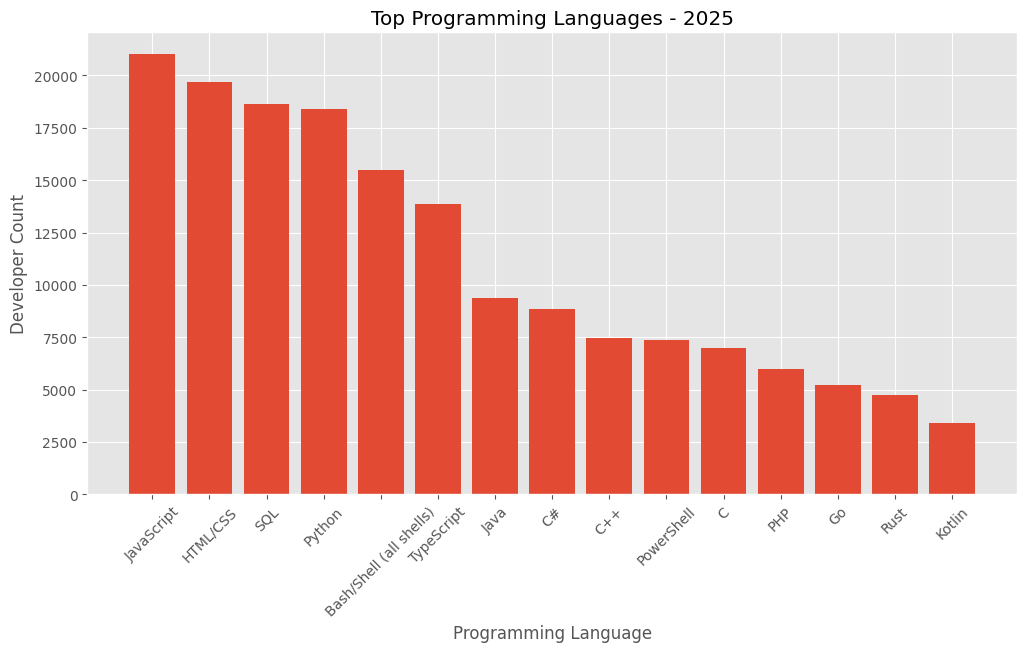

In [8]:
top_lang = languages.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top_lang["LanguageHaveWorkedWith"],
    top_lang["len"]
)

plt.xticks(rotation=45)

plt.title(
    "Top Programming Languages - 2025"
)

plt.xlabel("Programming Language")
plt.ylabel("Developer Count")

plt.show()

In [9]:
print("Technology Insight")

print(
    f"Most Used Programming Language: {languages['LanguageHaveWorkedWith'][0]}"
)

print(
    f"Developer Count: {languages['len'][0]}"
)

Technology Insight
Most Used Programming Language: JavaScript
Developer Count: 21005


In [10]:
databases = technology_count(
    df,
    "DatabaseHaveWorkedWith"
)

databases.head(15)

DatabaseHaveWorkedWith,len
str,u32
"""PostgreSQL""",14529
"""MySQL""",10581
"""SQLite""",9798
"""Microsoft SQL Server""",7871
"""Redis""",7316
…,…
"""BigQuery""",1705
"""Supabase""",1558
"""Cloud Firestore""",1494


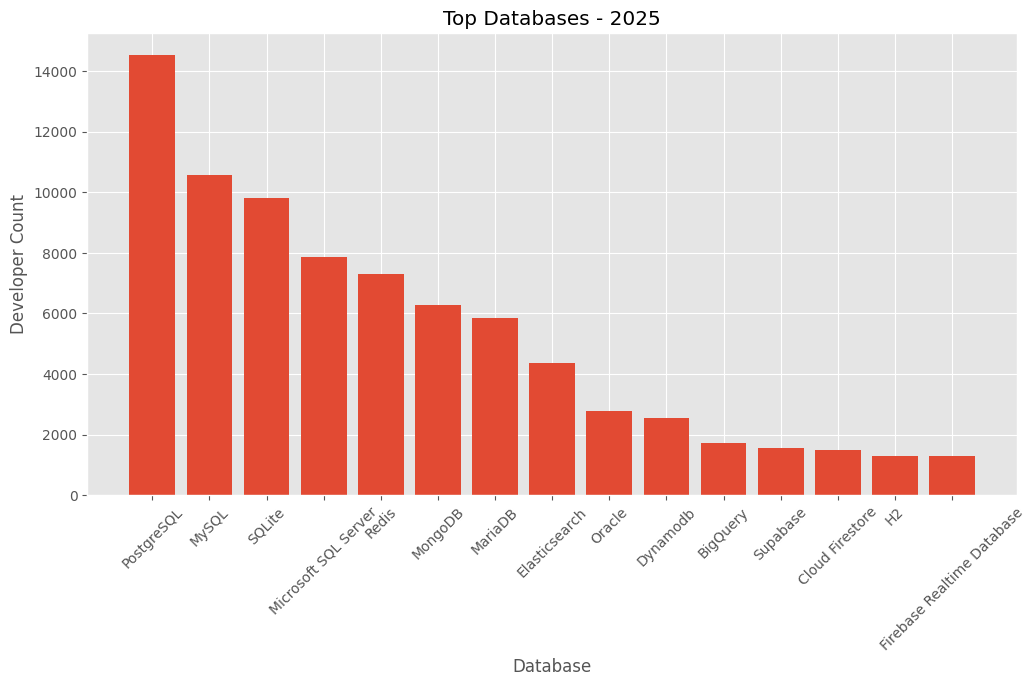

In [11]:
top_db = databases.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top_db["DatabaseHaveWorkedWith"],
    top_db["len"]
)

plt.xticks(rotation=45)

plt.title(
    "Top Databases - 2025"
)

plt.xlabel("Database")
plt.ylabel("Developer Count")

plt.show()

In [12]:
print("INSIGHT")

print(
    f"The most popular database is {databases[0,0]}."
)

print(
    "Database technologies continue to be a critical part of application development."
)

INSIGHT
The most popular database is PostgreSQL.
Database technologies continue to be a critical part of application development.


In [13]:
frameworks = technology_count(
    df,
    "WebframeHaveWorkedWith"
)

frameworks.head(15)

WebframeHaveWorkedWith,len
str,u32
"""Node.js""",11544
"""React""",10596
"""jQuery""",5541
"""Next.js""",4933
"""Express""",4710
…,…
"""Flask""",3406
"""ASP.NET""",3360
"""WordPress""",3227


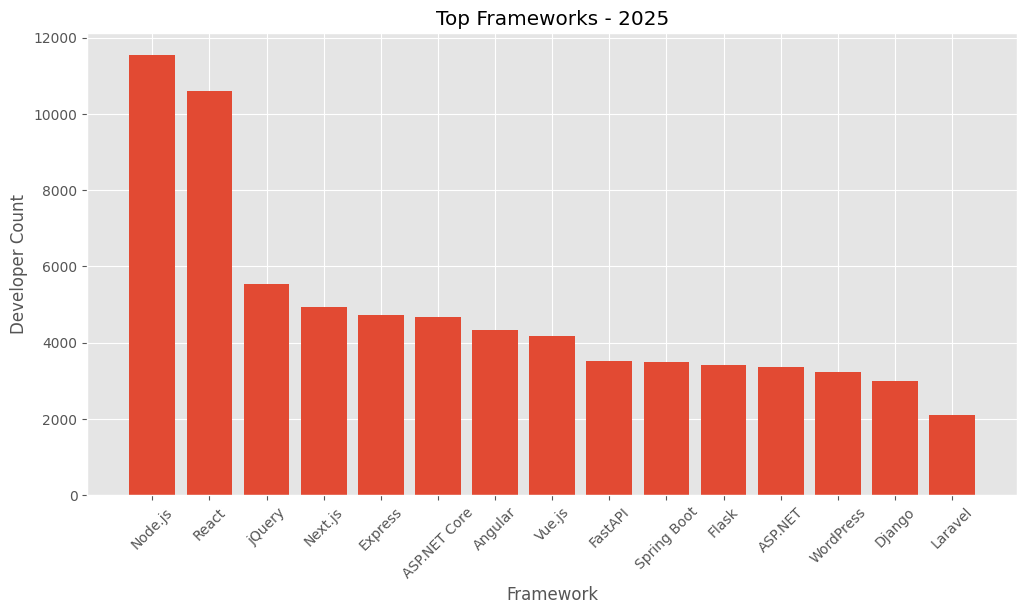

In [14]:
top_frameworks = frameworks.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top_frameworks["WebframeHaveWorkedWith"],
    top_frameworks["len"]
)

plt.xticks(rotation=45)

plt.title(
    "Top Frameworks - 2025"
)

plt.xlabel("Framework")
plt.ylabel("Developer Count")

plt.show()

In [15]:
print("Technology Insight")

print(
    f"Most Used Framework: {frameworks['WebframeHaveWorkedWith'][0]}"
)

print(
    f"Developer Count: {frameworks['len'][0]}"
)

Technology Insight
Most Used Framework: Node.js
Developer Count: 11544


In [16]:
platforms = technology_count(
    df,
    "PlatformHaveWorkedWith"
)

platforms.head(15)

PlatformHaveWorkedWith,len
str,u32
"""Docker""",17414
"""npm""",13906
"""Amazon Web Services (AWS)""",10618
"""Pip""",10025
"""Kubernetes""",6993
…,…
"""Yarn""",5178
"""Cloudflare""",4923
"""NuGet""",4637


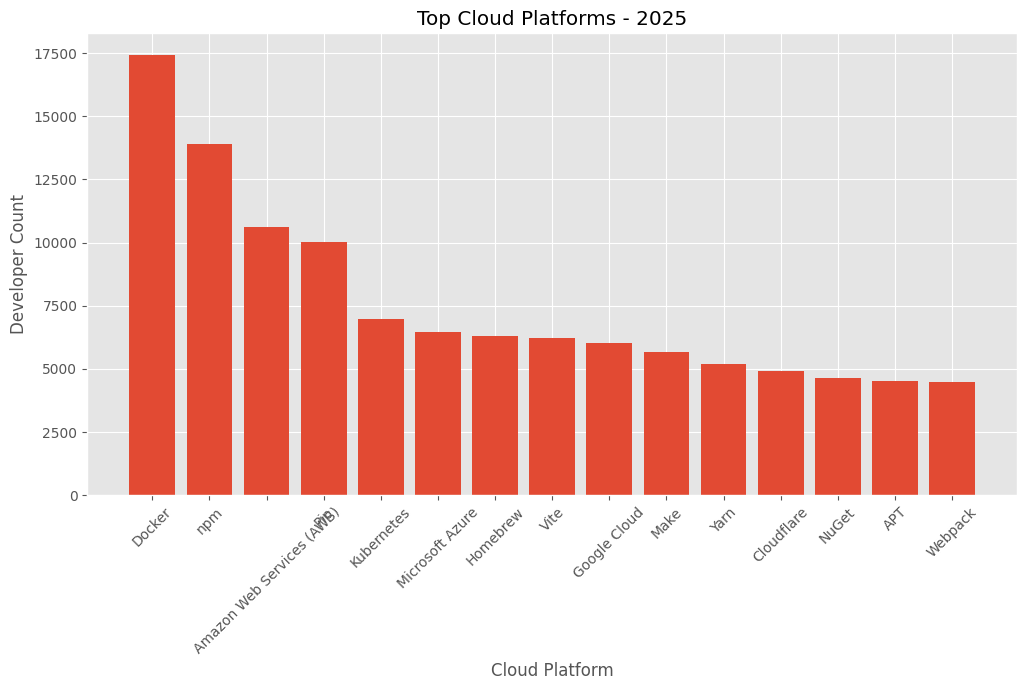

In [17]:
top_platforms = platforms.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top_platforms["PlatformHaveWorkedWith"],
    top_platforms["len"]
)

plt.xticks(rotation=45)

plt.title(
    "Top Cloud Platforms - 2025"
)

plt.xlabel("Cloud Platform")
plt.ylabel("Developer Count")

plt.show()

In [18]:
print("Technology Insight")

print(
    f"Most Used Cloud Platform: {platforms['PlatformHaveWorkedWith'][0]}"
)

print(
    f"Developer Count: {platforms['len'][0]}"
)

Technology Insight
Most Used Cloud Platform: Docker
Developer Count: 17414


In [19]:
desired_languages = technology_count(
    df,
    "LanguageWantToWorkWith"
)

desired_languages.head(15)

LanguageWantToWorkWith,len
str,u32
"""Python""",12419
"""SQL""",11257
"""HTML/CSS""",10661
"""JavaScript""",10581
"""TypeScript""",10099
…,…
"""Java""",4981
"""C""",4548
"""Kotlin""",3786


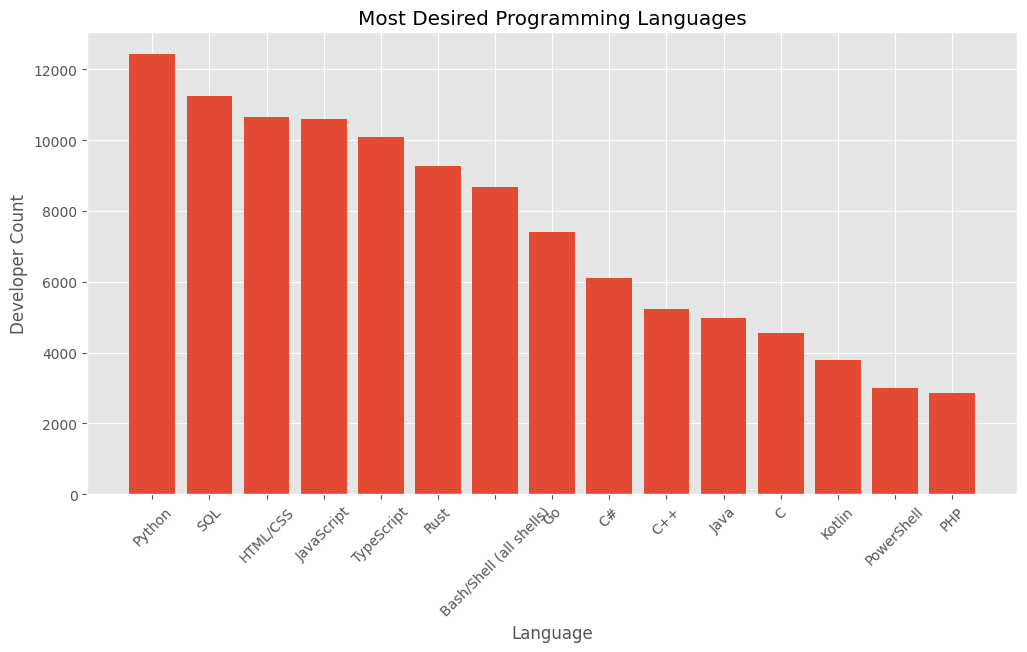

In [20]:
top_desired = desired_languages.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top_desired["LanguageWantToWorkWith"],
    top_desired["len"]
)

plt.xticks(rotation=45)

plt.title(
    "Most Desired Programming Languages"
)

plt.xlabel("Language")
plt.ylabel("Developer Count")

plt.show()

In [21]:
print("Technology Insight")

print(
    f"Most Desired Language: {desired_languages['LanguageWantToWorkWith'][0]}"
)

print(
    f"Developer Count: {desired_languages['len'][0]}"
)

Technology Insight
Most Desired Language: Python
Developer Count: 12419


In [22]:
summary = pl.DataFrame({

    "Category":[
        "Programming Language",
        "Database",
        "Framework",
        "Cloud Platform",
        "Desired Language"
    ],

    "Leader":[
        languages["LanguageHaveWorkedWith"][0],
        databases["DatabaseHaveWorkedWith"][0],
        frameworks["WebframeHaveWorkedWith"][0],
        platforms["PlatformHaveWorkedWith"][0],
        desired_languages["LanguageWantToWorkWith"][0]
    ],

    "Developer_Count":[
        languages["len"][0],
        databases["len"][0],
        frameworks["len"][0],
        platforms["len"][0],
        desired_languages["len"][0]
    ]
})

summary

Category,Leader,Developer_Count
str,str,i64
"""Programming Language""","""JavaScript""",21005
"""Database""","""PostgreSQL""",14529
"""Framework""","""Node.js""",11544
"""Cloud Platform""","""Docker""",17414
"""Desired Language""","""Python""",12419


In [23]:
print("===== TECHNOLOGY TREND INTELLIGENCE PLATFORM =====\n")

print(
    f"Top Programming Language : {languages['LanguageHaveWorkedWith'][0]}"
)

print(
    f"Top Database : {databases['DatabaseHaveWorkedWith'][0]}"
)

print(
    f"Top Framework : {frameworks['WebframeHaveWorkedWith'][0]}"
)

print(
    f"Top Cloud Platform : {platforms['PlatformHaveWorkedWith'][0]}"
)

print(
    f"Most Desired Language : {desired_languages['LanguageWantToWorkWith'][0]}"
)

print("\nKey Insight")

print(
    "The analysis shows the most widely adopted technologies "
    "among developers in the Stack Overflow Developer Survey 2025. "
    "These technologies represent current industry preferences and "
    "future developer interests."
)

===== TECHNOLOGY TREND INTELLIGENCE PLATFORM =====

Top Programming Language : JavaScript
Top Database : PostgreSQL
Top Framework : Node.js
Top Cloud Platform : Docker
Most Desired Language : Python

Key Insight
The analysis shows the most widely adopted technologies among developers in the Stack Overflow Developer Survey 2025. These technologies represent current industry preferences and future developer interests.


In [24]:
!pip install -q streamlit pyngrok polars pyarrow matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 45.0 MB/s eta 0:00:00


In [25]:
%%writefile app.py
import streamlit as st
import polars as pl
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Technology Trend Intelligence Platform",
    page_icon="📈",
    layout="wide"
)

st.title("📈 Technology Trend Intelligence Platform")

DATA_URL = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv"

@st.cache_data
def load_data():
    return pl.read_csv(DATA_URL, ignore_errors=True)

df = load_data()


def technology_count(df, column_name):

    result = (
        df
        .select(column_name)
        .drop_nulls()
        .with_columns(
            pl.col(column_name).str.split(";")
        )
        .explode(column_name)
        .group_by(column_name)
        .len()
        .sort("len", descending=True)
    )

    return result


st.sidebar.title("Navigation")

page = st.sidebar.selectbox(
    "Choose Page",
    [
        "Dataset Overview",
        "Programming Languages",
        "Databases",
        "Frameworks",
        "Cloud Platforms",
        "Desired Languages"
    ]
)

if page == "Dataset Overview":

    st.subheader("Dataset Preview")

    st.write("Rows:", df.height)
    st.write("Columns:", df.width)

    st.dataframe(df.head(10).to_pandas())

elif page == "Programming Languages":

    lang = technology_count(df, "LanguageHaveWorkedWith").head(15)

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(lang["LanguageHaveWorkedWith"], lang["len"])

    plt.xticks(rotation=45)

    st.pyplot(fig)

elif page == "Databases":

    db = technology_count(df, "DatabaseHaveWorkedWith").head(15)

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(db["DatabaseHaveWorkedWith"], db["len"])

    plt.xticks(rotation=45)

    st.pyplot(fig)

elif page == "Frameworks":

    fw = technology_count(df, "WebframeHaveWorkedWith").head(15)

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(fw["WebframeHaveWorkedWith"], fw["len"])

    plt.xticks(rotation=45)

    st.pyplot(fig)

elif page == "Cloud Platforms":

    platform = technology_count(df, "PlatformHaveWorkedWith").head(15)

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(platform["PlatformHaveWorkedWith"], platform["len"])

    plt.xticks(rotation=45)

    st.pyplot(fig)

elif page == "Desired Languages":

    desired = technology_count(df, "LanguageWantToWorkWith").head(15)

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(desired["LanguageWantToWorkWith"], desired["len"])

    plt.xticks(rotation=45)

    st.pyplot(fig)

Writing app.py


In [26]:
!streamlit run app.py &>/content/logs.txt &

In [28]:
from pyngrok import ngrok

ngrok.set_auth_token("34YNTAGVw3aYDYO61Rg8LIQjmf1_5N8ojgpMFqA3ayw73vEEE")

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://undeviatingly-vacillant-sharyn.ngrok-free.dev" -> "http://localhost:8501"
